# Forecasting electricity demand in Lithuania

Data is available [here](https://data.gov.lt/datasets/2903/?resource_version=705).

#### Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#### Dataset import

In [2]:
data = pd.read_csv('./data/vartojimas-203.csv',
                   engine='pyarrow',
                   parse_dates=['ltu', 'utc'])

#### Dataset overview

In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27361 entries, 0 to 27360
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype        
---  ------  --------------  -----        
 0   id      27361 non-null  int64        
 1   value   27361 non-null  float64      
 2   ltu     27361 non-null  datetime64[s]
 3   utc     27361 non-null  datetime64[s]
dtypes: datetime64[s](2), float64(1), int64(1)
memory usage: 855.2 KB


Our dataset contains 3 useful columns: `value` (de facto national energy consumption in MW), `ltu` (time in Lithuania) and `utc`.

In [4]:
data.head()

,id,value,ltu,utc
0,203,978.868,2023-01-01 02:00:00,2023-01-01 00:00:00
1,203,947.675,2023-01-01 03:00:00,2023-01-01 01:00:00
2,203,937.409,2023-01-01 04:00:00,2023-01-01 02:00:00
3,203,933.605,2023-01-01 05:00:00,2023-01-01 03:00:00
4,203,961.825,2023-01-01 06:00:00,2023-01-01 04:00:00


In [5]:
data = data.drop(columns=['id'])

In [6]:
data

,value,ltu,utc
0,978.868,2023-01-01 02:00:00,2023-01-01 00:00:00
1,947.675,2023-01-01 03:00:00,2023-01-01 01:00:00
2,937.409,2023-01-01 04:00:00,2023-01-01 02:00:00
3,933.605,2023-01-01 05:00:00,2023-01-01 03:00:00
4,961.825,2023-01-01 06:00:00,2023-01-01 04:00:00
...,...,...,...
27356,1741.394,2026-02-13 22:00:00,2026-02-13 20:00:00
27357,1643.696,2026-02-13 23:00:00,2026-02-13 21:00:00
27358,1574.306,2026-02-14 00:00:00,2026-02-13 22:00:00
27359,1533.344,2026-02-14 01:00:00,2026-02-13 23:00:00


In [7]:
data[data.value == 0]

,value,ltu,utc


In [8]:
data.value.isna().sum()

np.int64(0)

In [9]:
data['date'] = data['ltu'].dt.date

In [10]:
data['day_of_week'] = data['ltu'].dt.day_of_week

In [11]:
data['month'] = data['ltu'].dt.month

In [12]:
data['year'] = data['ltu'].dt.year

#### Time series overview

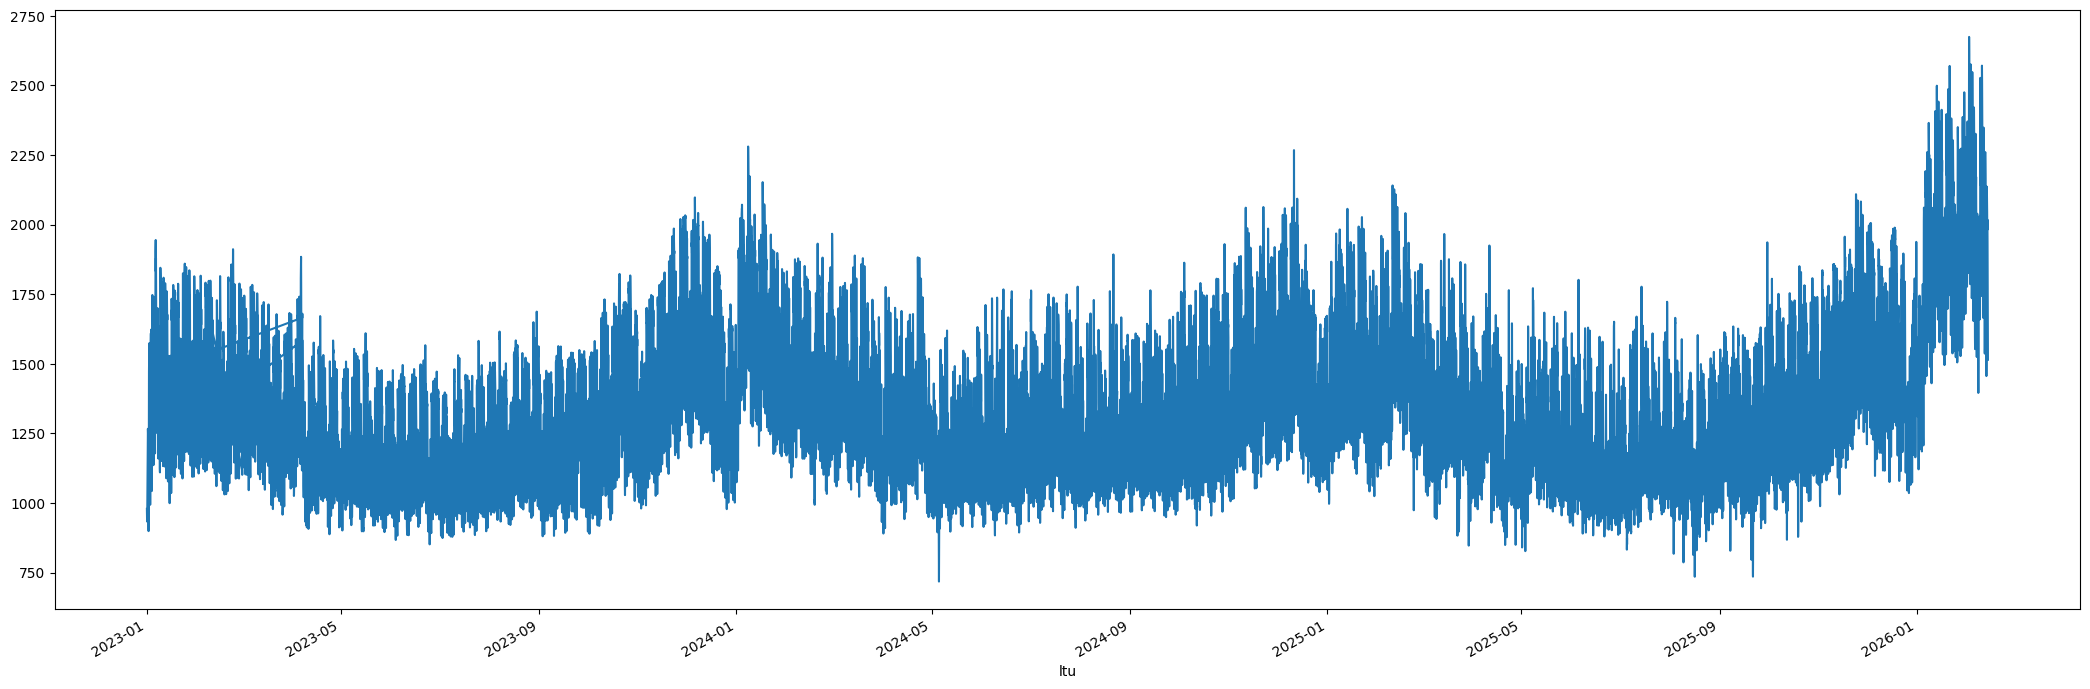

In [13]:
fig, ax = plt.subplots(1, 1, figsize=(21, 7))

data.plot(x='ltu',
          y='value',
          legend=False,
          ax=ax)

plt.tight_layout()
plt.show()

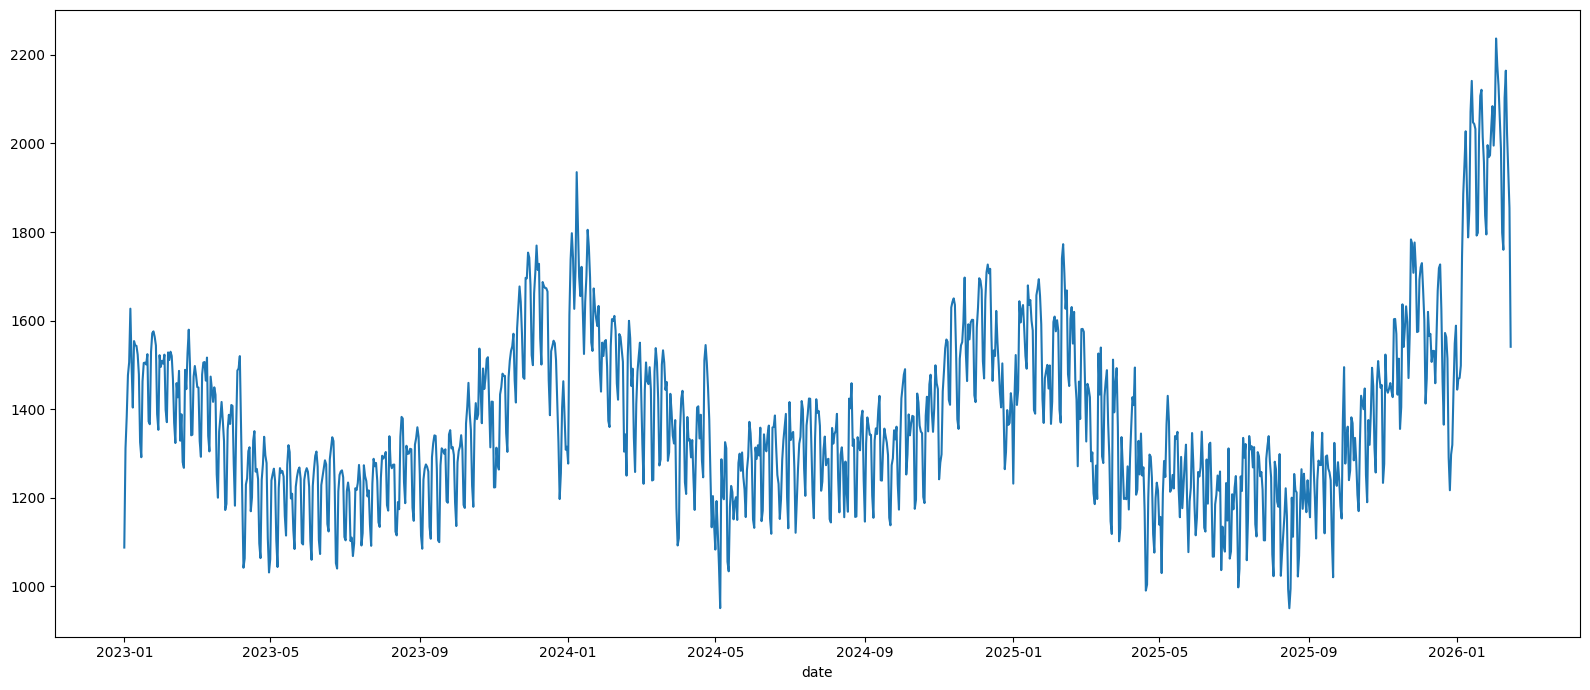

In [14]:
fig, ax = plt.subplots(1, 1, figsize=(16, 7))

data.groupby('date')['value'].mean().plot(ax=ax)

plt.tight_layout()
plt.show()

#### Weather data

In [15]:
weather = pd.read_csv('./data/Matavimas.csv',
                      engine='pyarrow')

In [16]:
weather.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2430012 entries, 0 to 2430011
Data columns (total 20 columns):
 #   Column               Dtype        
---  ------               -----        
 0   _type                object       
 1   _id                  object       
 2   _revision            object       
 3   _page.next           object       
 4   vda_prime_key        object       
 5   stoties_pavadinimas  object       
 6   stoties_kodas        object       
 7   ilguma               float64      
 8   platuma              float64      
 9   stebejimo_laikas     datetime64[s]
 10  oro_temp             float64      
 11  juntamoji_temp       float64      
 12  vejo_greitis         float64      
 13  vejo_gusis           float64      
 14  vejo_kryptis         float64      
 15  debesuotumas         float64      
 16  slegis_juros_lyg     float64      
 17  santyk_oro_dregme    float64      
 18  kritutliu_kiekis     float64      
 19  oro_salygos          object       
dtypes:

In [17]:
weather = weather.drop(columns=['_type', '_id', '_revision', '_page.next', 'vda_prime_key'])

In [18]:
weather = weather[weather['stebejimo_laikas'].between(min(data['ltu']), max(data['ltu']))]

In [19]:
weather = weather.sort_values('stebejimo_laikas').reset_index(drop=True)

In [20]:
weather.head()

,stoties_pavadinimas,stoties_kodas,ilguma,platuma,stebejimo_laikas,oro_temp,juntamoji_temp,vejo_greitis,vejo_gusis,vejo_kryptis,debesuotumas,slegis_juros_lyg,santyk_oro_dregme,kritutliu_kiekis,oro_salygos
0,Ukmergės AMS,ukmerges-ams,24.760335,55.264145,2023-01-01 02:00:00,10.0,10.0,3.2,6.3,209.0,88.0,1005.9,96.0,0.3,nedidelis lietus
1,Biržų AMS,birzu-ams,24.774184,56.193191,2023-01-01 02:00:00,9.6,9.6,2.9,6.0,242.0,100.0,1003.2,99.0,0.2,nedidelis lietus
2,Panevėžio AMS,panevezio-ams,24.417184,55.735154,2023-01-01 02:00:00,10.3,10.3,4.6,8.8,210.0,88.0,1004.5,97.0,0.3,nedidelis lietus
3,Kauno AMS,kauno-ams,23.835880,54.883960,2023-01-01 02:00:00,11.4,11.4,4.5,8.5,242.0,100.0,1006.8,93.0,0.1,nedidelis lietus
4,Šiaulių AMS,siauliu-ams,23.331111,55.942222,2023-01-01 02:00:00,10.5,10.5,2.8,5.6,238.0,100.0,1003.6,95.0,1.0,nedidelis lietus


In [21]:
ams_to_city = {
  'Klaipėdos AMS': 'Klaipėda',
  'Nidos AMS': 'Neringa',
  'Raseinių AMS': 'Raseiniai',
  'Panevėžio AMS': 'Panevėžys',
  'Kauno AMS': 'Kaunas',
  'Varėnos AMS': 'Varėna',
  'Šiaulių AMS': 'Šiauliai',
  'Laukuvos AMS': 'Šilalė',
  'Dūkšto AMS': 'Ignalina',
  'Dotnuvos AMS': 'Kėdainiai',
  'Telšių AMS': 'Telšiai',
  'Šilutės AMS': 'Šilutė',
  'Utenos AMS': 'Utena',
  'Biržų AMS': 'Biržai',
  'Kybartų AMS': 'Vilkaviškis',
  'Lazdijų AMS': 'Lazdijai',
  'Vilniaus AMS': 'Vilnius',
  'Ukmergės AMS': 'Ukmergė',
  'Molėtų AMS': 'Molėtai',
  'Birštono AMS': 'Birštonas',
  'Vėžaičių AMS': 'Vėžaičiai',
  'Kretingos AMS': 'Kretinga',
  'Prienų AMS': 'Prienai',
  'Zarasų AMS': 'Zarasai',
  'Alytaus AMS': 'Alytus',
  'Kalvarijos AMS': 'Kalvarija',
  'Trakų AMS': 'Trakai',
  'Šeduvos AMS': 'Radviliškis',
  'Joniškio AMS': 'Joniškis',
  'Pakruojo AMS': 'Pakruojis',
  'Mažeikių AMS': 'Mažeikiai',
  'Šakių AMS': 'Šakiai',
  'Kelmės AMS': 'Kelmė',
  'Elektrėnų AMS': 'Elektrėnai',
  'Šalčininkų AMS': 'Šalčininkai',
  'Pagėgių AMS': 'Pagėgiai',
  'Druskininkų AMS': 'Druskininkai',
  'Rietavo AMS': 'Rietavas',
  'Skuodo AMS': 'Skuodas',
  'Švenčionių AMS': 'Švenčionys',
  'Rokiškio AMS': 'Rokiškis',
  'Anykščių AMS': 'Anykščiai',
  'Kaišiadorių AMS': 'Kaišiadorys',
  'Kupiškio AMS': 'Kupiškis',
  'Ventės AMS': 'Šilutė',
  'Jurbarko AMS': 'Jurbarkas',
  'Akmenės AMS': 'Akmenė',
  'Tauragės AMS': 'Tauragė',
  'Kazlų Rūdos AMS': 'Kazlų Rūda',
  'Plungės AMS': 'Plungė',
  'Marijampolės AMS': 'Marijampolė',
  'Jonavos AMS': 'Jonava',
  'Vėžaičių AMS': 'Klaipėda'
}

In [22]:
weather['city'] = weather['stoties_pavadinimas'].map(ams_to_city)

#### Population data

In [23]:
pop = pd.read_excel('./data/gyventojai-26-01.xlsx', header=1, index_col='Eil. nr.')

In [24]:
pop.columns

Index(['Savivaldybės pavadinimas', 'Bendras gyventojų skaičius', 'Vyrai',
       'Moterys', 'nuo 0 iki 6', 'nuo 7 iki 17', 'nuo 18 iki 29',
       'nuo 30 iki 39', 'nuo 40 iki 49', 'nuo 50 iki 59', 'nuo 60 iki 64',
       'nuo 65 iki 74', 'nuo 75 iki 84', 'nuo 85'],
      dtype='object')

In [25]:
muni_to_city = {
  'Akmenės r. sav.': 'Akmenė',
  'Alytaus m. sav.': 'Alytus',
  'Alytaus r. sav.': 'Alytus',
  'Anykščių r. sav.': 'Anykščiai',
  'Birštono sav.': 'Birštonas',
  'Biržų r. sav.': 'Biržai',
  'Druskininkų sav.': 'Druskininkai',
  'Elektrėnų sav.': 'Elektrėnai',
  'Ignalinos r. sav.': 'Ignalina',
  'Jonavos r. sav.': 'Jonava',
  'Joniškio r. sav.': 'Joniškis',
  'Jurbarko r. sav.': 'Jurbarkas',
  'Kaišiadorių r. sav.': 'Kaišiadorys',
  'Kalvarijos sav.': 'Kalvarija',
  'Kauno m. sav.': 'Kaunas',
  'Kauno r. sav.': 'Kaunas',
  'Kazlų Rūdos sav.': 'Kazlų Rūda',
  'Kelmės r. sav.': 'Kelmė',
  'Klaipėdos m. sav.': 'Klaipėda',
  'Klaipėdos r. sav.': 'Klaipėda',
  'Kretingos r. sav.': 'Kretinga',
  'Kupiškio r. sav.': 'Kupiškis',
  'Kėdainių r. sav.': 'Kėdainiai',
  'Lazdijų r. sav.': 'Lazdijai',
  'Marijampolės sav.': 'Marijampolė',
  'Mažeikių r. sav.': 'Mažeikiai',
  'Molėtų r. sav.': 'Molėtai',
  'Neringos sav.': 'Neringa',
  'Pagėgių sav.': 'Pagėgiai',
  'Pakruojo r. sav.': 'Pakruojis',
  'Palangos m. sav.': 'Palanga',
  'Panevėžio m. sav.': 'Panevėžys',
  'Panevėžio r. sav.': 'Panevėžys',
  'Pasvalio r. sav.': 'Pasvalys',
  'Plungės r. sav.': 'Plungė',
  'Prienų r. sav.': 'Prienai',
  'Radviliškio r. sav.': 'Radviliškis',
  'Raseinių r. sav.': 'Raseiniai',
  'Rietavo sav.': 'Rietavas',
  'Rokiškio r. sav.': 'Rokiškis',
  'Skuodo r. sav.': 'Skuodas',
  'Tauragės r. sav.': 'Tauragė',
  'Telšių r. sav.': 'Telšiai',
  'Trakų r. sav.': 'Trakai',
  'Ukmergės r. sav.': 'Ukmergė',
  'Utenos r. sav.': 'Utena',
  'Varėnos r. sav.': 'Varėna',
  'Vilkaviškio r. sav.': 'Vilkaviškis',
  'Vilniaus m. sav.': 'Vilnius',
  'Vilniaus r. sav.': 'Vilnius',
  'Visagino sav.': 'Visaginas',
  'Zarasų r. sav.': 'Zarasai',
  'Šakių r. sav.': 'Šakiai',
  'Šalčininkų r. sav.': 'Šalčininkai',
  'Šiaulių m. sav.': 'Šiauliai',
  'Šiaulių r. sav.': 'Šiauliai',
  'Šilalės r. sav.': 'Šilalė',
  'Šilutės r. sav.': 'Šilutė',
  'Širvintų r. sav.': 'Širvintos',
  'Švenčionių r. sav.': 'Švenčionys'
}

In [26]:
pop['city'] = pop['Savivaldybės pavadinimas'].map(muni_to_city)

In [27]:
pop = pop.groupby('city')['Bendras gyventojų skaičius'].sum()

In [28]:
weather = weather.merge(pop, on='city', how='left').rename(columns={'Bendras gyventojų skaičius':'gyventoju_skaicius'})

In [29]:
weather

,stoties_pavadinimas,stoties_kodas,ilguma,platuma,stebejimo_laikas,oro_temp,juntamoji_temp,vejo_greitis,vejo_gusis,vejo_kryptis,debesuotumas,slegis_juros_lyg,santyk_oro_dregme,kritutliu_kiekis,oro_salygos,city,gyventoju_skaicius
0,Ukmergės AMS,ukmerges-ams,24.760335,55.264145,2023-01-01 02:00:00,10.0,10.0,3.2,6.3,209.0,88.0,1005.9,96.0,0.3,nedidelis lietus,Ukmergė,35810
1,Biržų AMS,birzu-ams,24.774184,56.193191,2023-01-01 02:00:00,9.6,9.6,2.9,6.0,242.0,100.0,1003.2,99.0,0.2,nedidelis lietus,Biržai,22987
2,Panevėžio AMS,panevezio-ams,24.417184,55.735154,2023-01-01 02:00:00,10.3,10.3,4.6,8.8,210.0,88.0,1004.5,97.0,0.3,nedidelis lietus,Panevėžys,124558
3,Kauno AMS,kauno-ams,23.835880,54.883960,2023-01-01 02:00:00,11.4,11.4,4.5,8.5,242.0,100.0,1006.8,93.0,0.1,nedidelis lietus,Kaunas,432494
4,Šiaulių AMS,siauliu-ams,23.331111,55.942222,2023-01-01 02:00:00,10.5,10.5,2.8,5.6,238.0,100.0,1003.6,95.0,1.0,nedidelis lietus,Šiauliai,164217
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
895860,Marijampolės AMS,marijampoles-ams,23.351810,54.528855,2026-02-12 23:00:00,0.5,-1.5,1.7,3.6,98.0,NaN,NaN,94.0,0.0,None,Marijampolė,56045
895861,Vilniaus AMS,vilniaus-ams,25.107064,54.625992,2026-02-12 23:00:00,0.4,0.4,1.0,1.8,66.0,NaN,988.5,98.0,0.0,rūkas,Vilnius,763563
895862,Pakruojo AMS,pakruojo-ams,23.902854,56.083488,2026-02-12 23:00:00,-4.8,NaN,NaN,NaN,NaN,NaN,NaN,89.0,0.1,None,Pakruojis,18014
895863,Utenos AMS,utenos-ams,25.589692,55.515321,2026-02-12 23:00:00,-1.1,-3.3,1.7,4.6,38.0,100.0,989.7,94.0,0.0,debesuota,Utena,39481


In [30]:
weather[(weather.stoties_pavadinimas == 'Vilniaus AMS') & (weather.juntamoji_temp.isna())]

,stoties_pavadinimas,stoties_kodas,ilguma,platuma,stebejimo_laikas,oro_temp,juntamoji_temp,vejo_greitis,vejo_gusis,vejo_kryptis,debesuotumas,slegis_juros_lyg,santyk_oro_dregme,kritutliu_kiekis,oro_salygos,city,gyventoju_skaicius
511222,Vilniaus AMS,vilniaus-ams,25.107064,54.625992,2025-03-06 10:00:00,14.1,NaN,8.3,17.3,268.0,0.0,1014.6,NaN,0.0,giedra,Vilnius,763563
511285,Vilniaus AMS,vilniaus-ams,25.107064,54.625992,2025-03-06 11:00:00,14.8,NaN,8.8,15.8,270.0,0.0,1014.7,NaN,0.0,giedra,Vilnius,763563
817527,Vilniaus AMS,vilniaus-ams,25.107064,54.625992,2025-12-11 00:00:00,9.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,None,Vilnius,763563
817578,Vilniaus AMS,vilniaus-ams,25.107064,54.625992,2025-12-11 01:00:00,8.8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,None,Vilnius,763563
839986,Vilniaus AMS,vilniaus-ams,25.107064,54.625992,2025-12-29 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,Vilnius,763563
840029,Vilniaus AMS,vilniaus-ams,25.107064,54.625992,2025-12-29 01:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,Vilnius,763563
840100,Vilniaus AMS,vilniaus-ams,25.107064,54.625992,2025-12-29 02:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,Vilnius,763563
840159,Vilniaus AMS,vilniaus-ams,25.107064,54.625992,2025-12-29 03:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,Vilnius,763563
840208,Vilniaus AMS,vilniaus-ams,25.107064,54.625992,2025-12-29 04:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,Vilnius,763563
840220,Vilniaus AMS,vilniaus-ams,25.107064,54.625992,2025-12-29 05:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,Vilnius,763563


In [31]:
weather['vejo_greitis'].isna().groupby(weather['stoties_pavadinimas']).mean().loc[lambda s: s < 0.7].index

Index(['Biržų AMS', 'Dotnuvos AMS', 'Dūkšto AMS', 'Kauno AMS', 'Klaipėdos AMS',
       'Kybartų AMS', 'Laukuvos AMS', 'Lazdijų AMS', 'Marijampolės AMS',
       'Mažeikių AMS', 'Nidos AMS', 'Panevėžio AMS', 'Raseinių AMS',
       'Rokiškio AMS', 'Tauragės AMS', 'Telšių AMS', 'Ukmergės AMS',
       'Utenos AMS', 'Varėnos AMS', 'Ventės AMS', 'Vilniaus AMS',
       'Vėžaičių AMS', 'Šiaulių AMS', 'Šilutės AMS', 'Švenčionių AMS'],
      dtype='object', name='stoties_pavadinimas')

In [32]:
weather[weather['stoties_pavadinimas'] == 'Pakruojo AMS']['juntamoji_temp'].isna().sum() / len(weather[weather['stoties_pavadinimas'] == 'Pakruojo AMS']['juntamoji_temp'])

np.float64(1.0)

In [33]:
weather['vejo_greitis'].isna().sum() / len(weather['vejo_greitis'])

np.float64(0.3759695936329693)

In [34]:
weather[weather['gyventoju_skaicius'].isna()]['stoties_pavadinimas'].unique()

array([], dtype=object)

In [35]:
weighted_temp = (
    (weather['oro_temp'] * weather['gyventoju_skaicius'])
    .groupby(weather['stebejimo_laikas'])
    .sum()
    / weather.groupby('stebejimo_laikas')['gyventoju_skaicius'].sum()
)

In [36]:
weighted_temp.isna().sum()

np.int64(0)

In [37]:
weighted_temp

stebejimo_laikas
2023-01-01 02:00:00     9.591937
2023-01-01 03:00:00     9.468869
2023-01-01 04:00:00     9.398759
2023-01-01 05:00:00     9.352938
2023-01-01 06:00:00    10.093947
                         ...    
2026-02-12 19:00:00    -1.981541
2026-02-12 20:00:00    -2.106984
2026-02-12 21:00:00    -2.926862
2026-02-12 22:00:00    -2.866254
2026-02-12 23:00:00    -1.917768
Length: 26235, dtype: float64

In [38]:
full_time = pd.Series(np.arange(min(data['utc']), max(data['utc']), dtype='datetime64[h]'))

In [39]:
full_time_df = pd.DataFrame(np.arange(min(data['utc']), max(data['utc']), dtype='datetime64[h]'), columns=['time'])

In [40]:
stations_series = pd.DataFrame(weather.stoties_kodas.unique(), columns=['station'])

In [41]:
full_time_station = full_time_df.merge(stations_series, how='cross')

In [42]:
weather.merge(full_time_station,
              left_on=['stebejimo_laikas', 'stoties_kodas'],
              right_on=['time', 'station'],
              how='right',
              indicator=True).query('_merge == "right_only"').drop(columns=['_merge']).shape

(526860, 19)

Filling missing values would require at least 3 hours of API requests since METEO API has a 120 RPM limit. We will interpolate values instead.

In [43]:
full_temp = weighted_temp.reindex(full_time).rename('weighted_temp').reset_index().rename(columns={'index': 'time'})

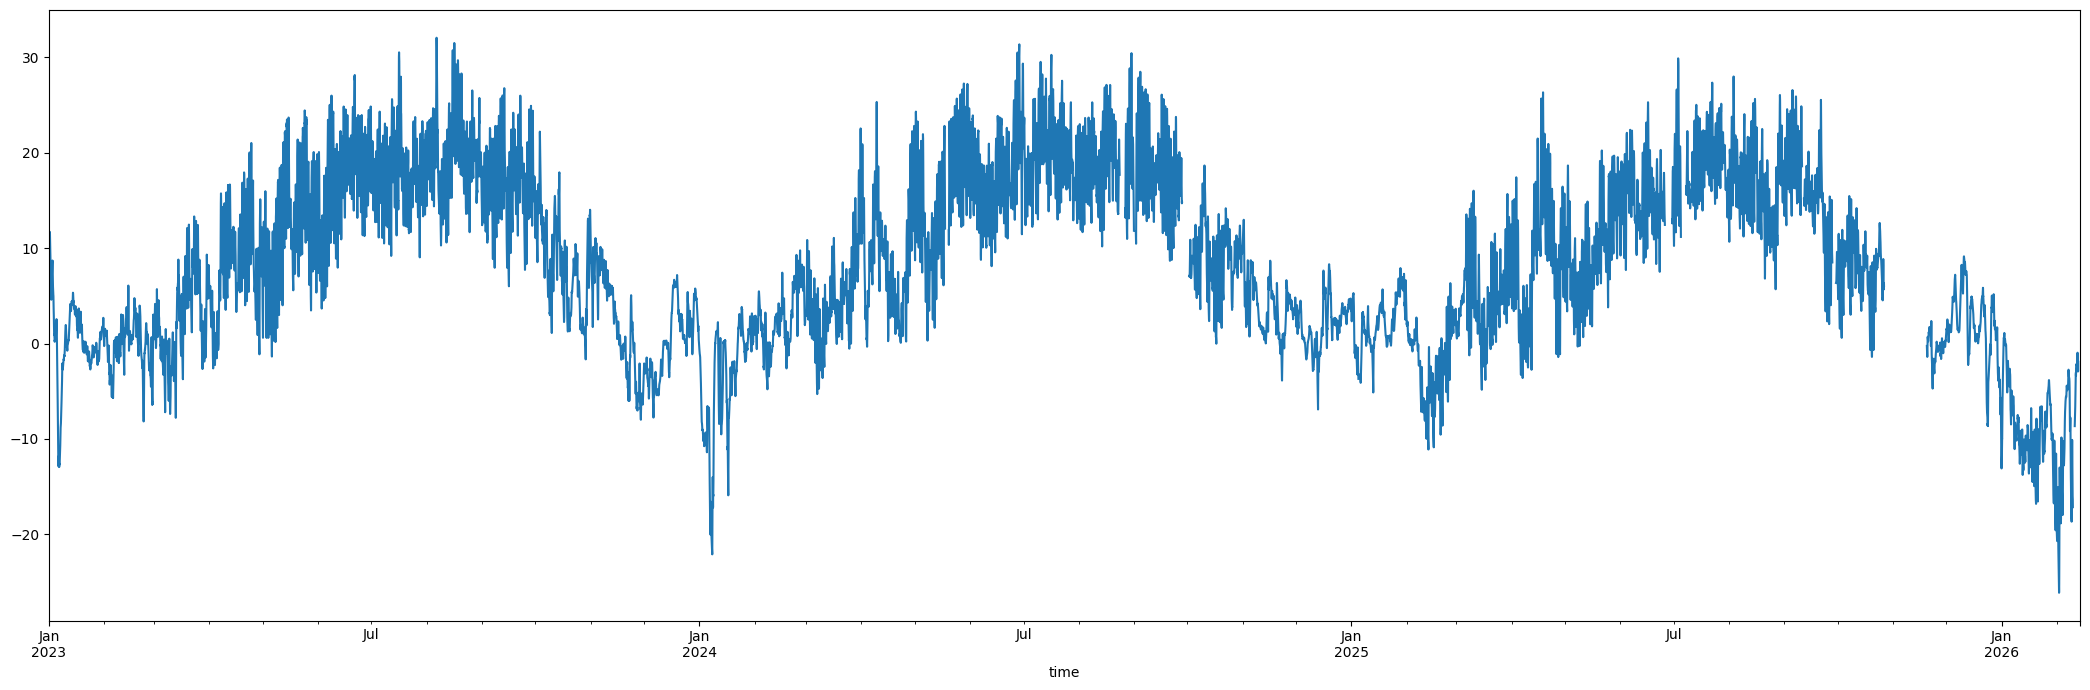

In [44]:
fig, ax = plt.subplots(1, 1, figsize=(21, 7))

full_temp.plot(x='time', y='weighted_temp', ax=ax, legend=False)

plt.tight_layout()
plt.show()

In [45]:
weighted_temp_df = pd.DataFrame(weighted_temp.reset_index(name='temp'))

In [46]:
weighted_temp_df['day'] = weighted_temp_df['stebejimo_laikas'].dt.day

In [47]:
weighted_temp_df['month'] = weighted_temp_df['stebejimo_laikas'].dt.month

In [48]:
weighted_temp_df['year'] = weighted_temp_df['stebejimo_laikas'].dt.year

In [49]:
weighted_temp_df['hour'] = weighted_temp_df['stebejimo_laikas'].dt.hour

In [50]:
weighted_temp_df['day_of_year'] = weighted_temp_df['stebejimo_laikas'].dt.day_of_year

In [51]:
weighted_temp_df

,stebejimo_laikas,temp,day,month,year,hour,day_of_year
0,2023-01-01 02:00:00,9.591937,1,1,2023,2,1
1,2023-01-01 03:00:00,9.468869,1,1,2023,3,1
2,2023-01-01 04:00:00,9.398759,1,1,2023,4,1
3,2023-01-01 05:00:00,9.352938,1,1,2023,5,1
4,2023-01-01 06:00:00,10.093947,1,1,2023,6,1
...,...,...,...,...,...,...,...
26230,2026-02-12 19:00:00,-1.981541,12,2,2026,19,43
26231,2026-02-12 20:00:00,-2.106984,12,2,2026,20,43
26232,2026-02-12 21:00:00,-2.926862,12,2,2026,21,43
26233,2026-02-12 22:00:00,-2.866254,12,2,2026,22,43


In [52]:
from sklearn.ensemble import RandomForestRegressor

temp_model = RandomForestRegressor()

X = weighted_temp_df[['hour', 'day', 'month', 'year', 'day_of_year']]

Y = weighted_temp_df[['temp']]

temp_model.fit(X, Y)

/home/user/Documents/repositories/power-forecast/.venv/lib/python3.12/site-packages/sklearn/base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [53]:
weighted_temp_df['predicted'] = temp_model.predict(X)

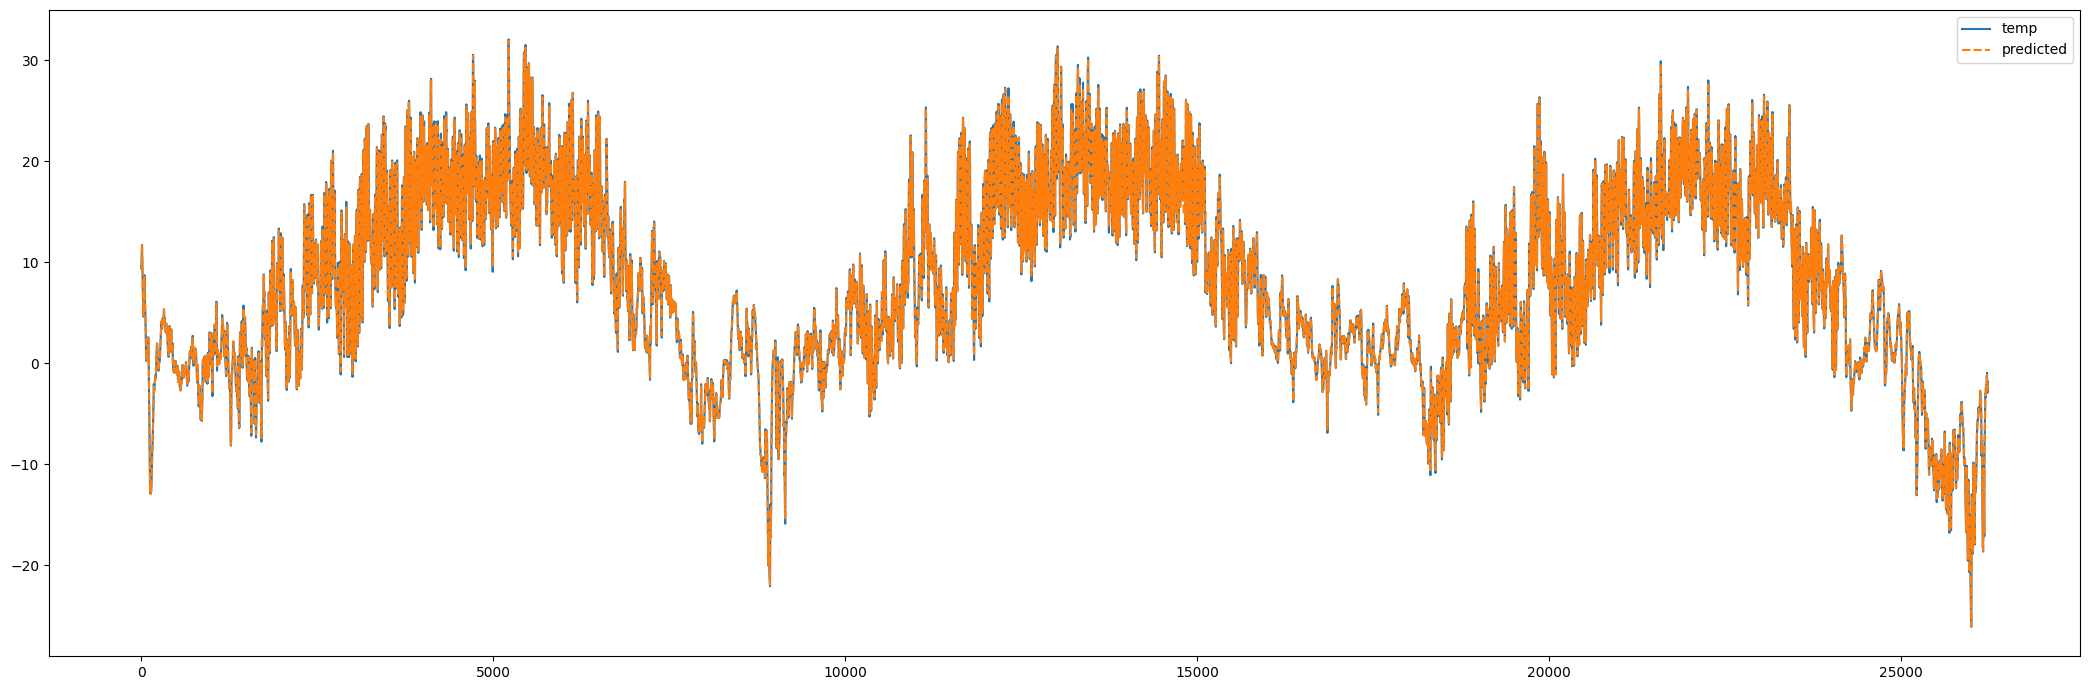

In [54]:
fig, ax = plt.subplots(1, 1, figsize=(21, 7))

sns.lineplot(weighted_temp_df[['temp', 'predicted']], ax=ax)

plt.tight_layout()
plt.show()

In [55]:
weighted_temp_df['diff'] = weighted_temp_df['temp'] - weighted_temp_df['predicted']

In [56]:
full_temp['day'] = full_temp['time'].dt.day
full_temp['month'] = full_temp['time'].dt.month
full_temp['year'] = full_temp['time'].dt.year
full_temp['hour'] = full_temp['time'].dt.hour
full_temp['day_of_year'] = full_temp['time'].dt.day_of_year

In [57]:
mask = full_temp.weighted_temp.isna()

full_temp.loc[mask, 'predicted'] = temp_model.predict(
    full_temp.loc[mask, ['hour', 'day', 'month', 'year', 'day_of_year']]
)

In [58]:
full_temp

,time,weighted_temp,day,month,year,hour,day_of_year,predicted
0,2023-01-01 00:00:00,NaN,1,1,2023,0,1,9.558685
1,2023-01-01 01:00:00,NaN,1,1,2023,1,1,9.558685
2,2023-01-01 02:00:00,9.591937,1,1,2023,2,1,NaN
3,2023-01-01 03:00:00,9.468869,1,1,2023,3,1,NaN
4,2023-01-01 04:00:00,9.398759,1,1,2023,4,1,NaN
...,...,...,...,...,...,...,...,...
27355,2026-02-13 19:00:00,NaN,13,2,2026,19,44,-2.008733
27356,2026-02-13 20:00:00,NaN,13,2,2026,20,44,-2.149886
27357,2026-02-13 21:00:00,NaN,13,2,2026,21,44,-2.645182
27358,2026-02-13 22:00:00,NaN,13,2,2026,22,44,-2.789725


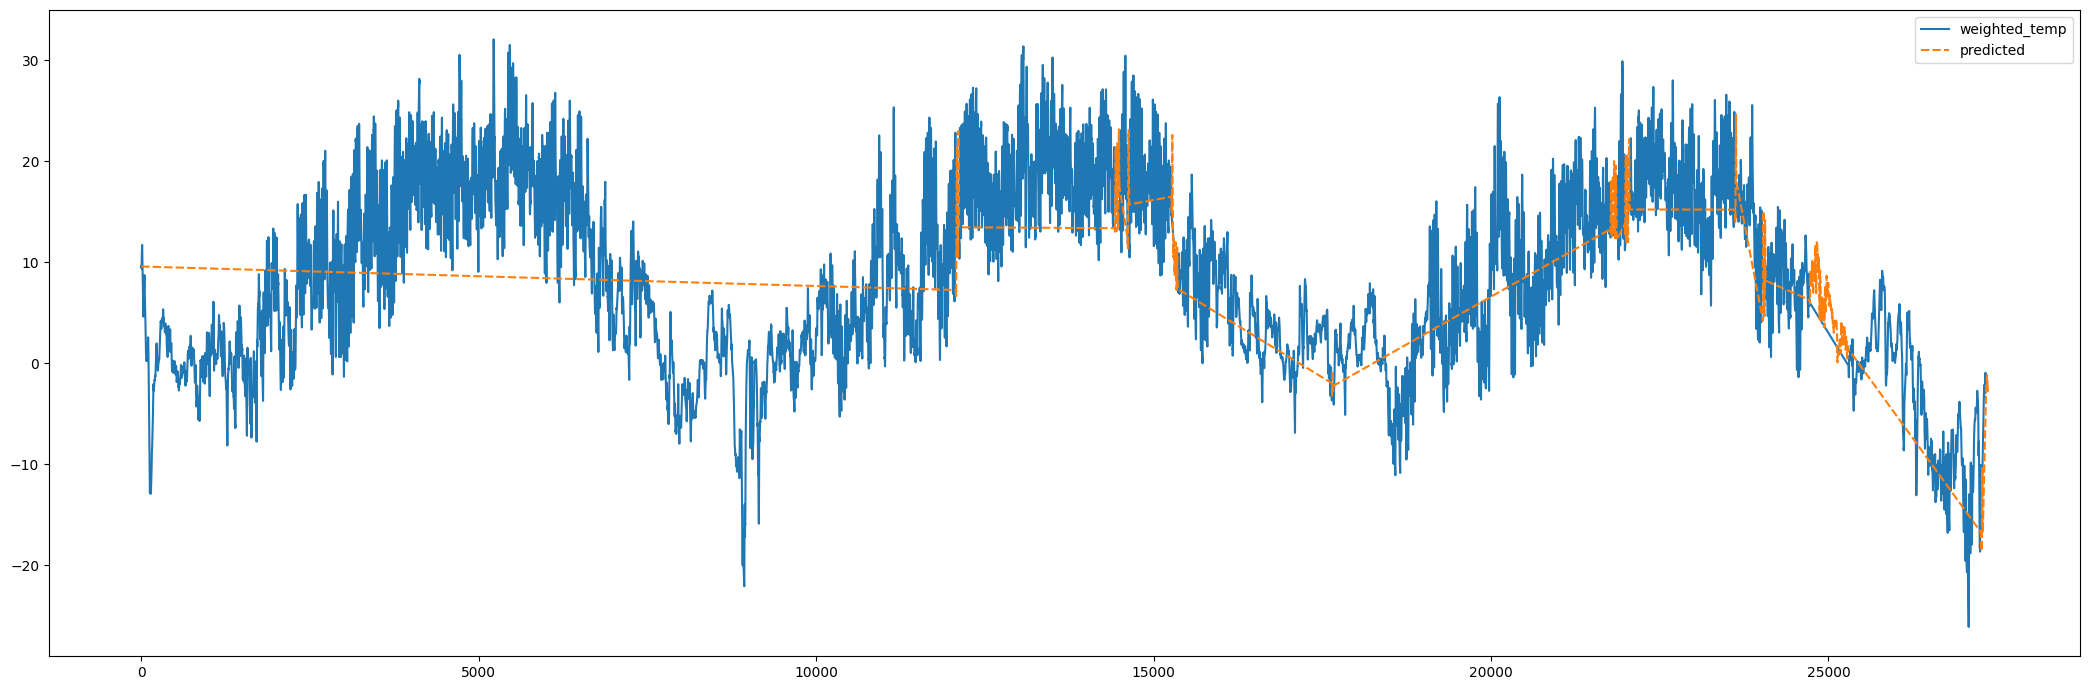

In [59]:
fig, ax = plt.subplots(1, 1, figsize=(21, 7))

sns.lineplot(full_temp[['time', 'weighted_temp', 'predicted']])

plt.tight_layout()
plt.show()

In [60]:
full_temp['final'] = full_temp['weighted_temp'].fillna(0) + full_temp['predicted'].fillna(0)

In [61]:
data = pd.merge(data, full_temp[['time', 'final']], left_on='utc', right_on='time').drop(columns='time').rename(columns={'final':'temp'})

#### Time series decomposition

##### Stationarity

In [62]:
import pmdarima

In [63]:
pmdarima.arima.ndiffs(data['value'], test='adf')

0

In [64]:
pmdarima.arima.ndiffs(data['value'], test='kpss')

1

In [65]:
pmdarima.arima.ndiffs(data['value'], test='pp')

0

ADF and Philips Perron tests indicate that there is no unit root present. Integration of the time series is not needed.

In [66]:
from pmdarima.arima.utils import nsdiffs

nsdiffs(data['value'],
        test='ocsb',
        m=8760,
        max_D=12)

0

Osborn, Chui, Smith, and Birchenhall test shows that seasonal differencing is also not necessary.

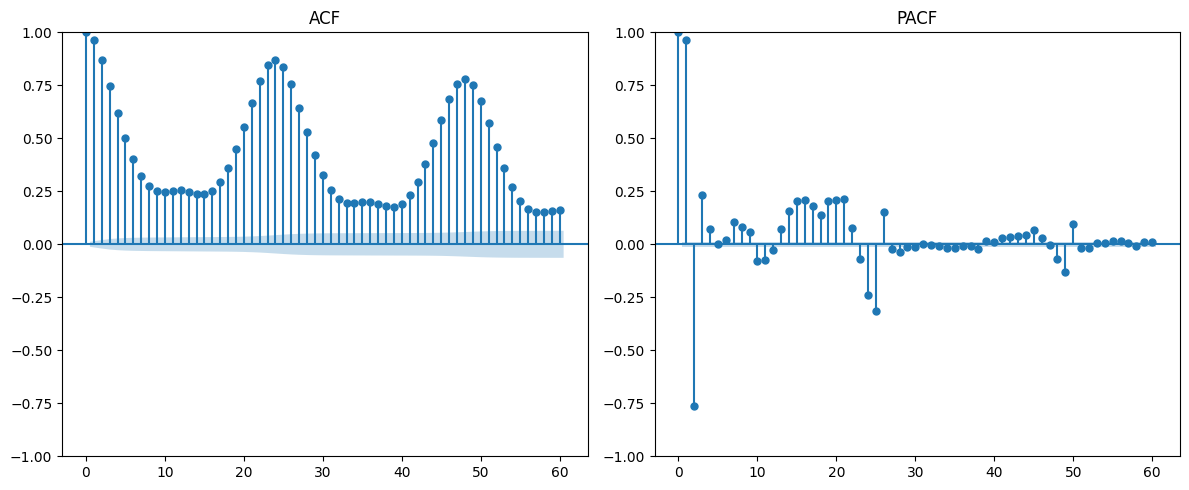

In [67]:
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.graphics.tsaplots import plot_pacf

fig, axs = plt.subplots(1, 2, figsize=(12, 5))

plot_acf(data["value"],
         lags=60,
         ax=axs[0])
axs[0].set_title("ACF")

plot_pacf(data["value"],
          lags=60,
          ax=axs[1])
axs[1].set_title('PACF')

plt.tight_layout()
plt.show()

The ACF chart is showning strong seasonality around every 24 hours, indicating that energy demand depends on the time of day. The PACF shows that energy demand is dependant on demand during the last hour.

In [68]:
from statsmodels.stats.diagnostic import acorr_ljungbox

print(acorr_ljungbox(data["value"], period=24)['lb_pvalue'].max())
print(acorr_ljungbox(data["value"], period=168)['lb_pvalue'].max())
print(acorr_ljungbox(data["value"], period=8760)['lb_pvalue'].max())

0.0
0.0
0.0


Since the p-value $ < 0.05$, we must reject the null hypothesis. The time series values are correlated.

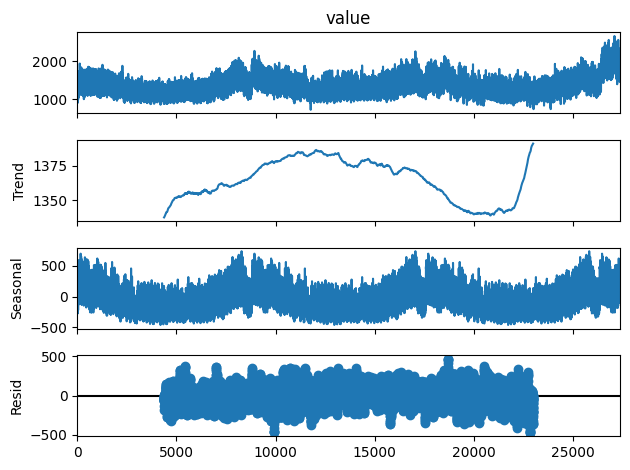

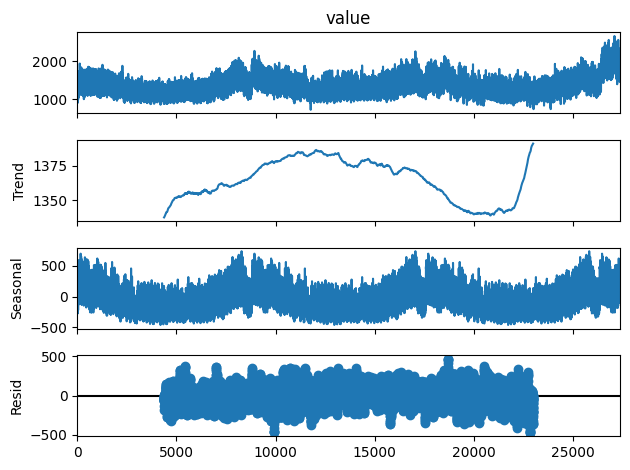

In [69]:
from statsmodels.tsa.seasonal import seasonal_decompose

ts = seasonal_decompose(data['value'],
                        model='additive',
                        period=8760)

ts.plot()

After decomposing the time series using moving averages, a few things become clearer. We see that there is some sort of trend of demand growth over the most recent period (winter of 2026) and an increase in demand post-COVID. The seasonal part of the time series is also strong, indicating that seasons play a role in energy demand. Large residuals also show that not all valuable information is extracted with this decomposition method.

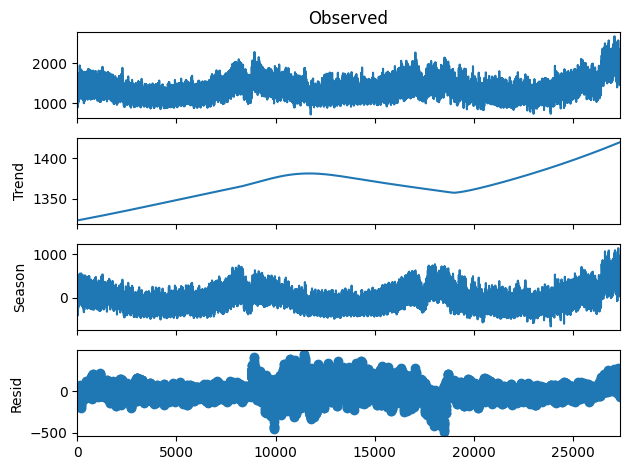

In [70]:
from statsmodels.tsa.seasonal import STL

stl = STL(data[['value']], period=8760)
result = stl.fit()

result.plot()
plt.show()

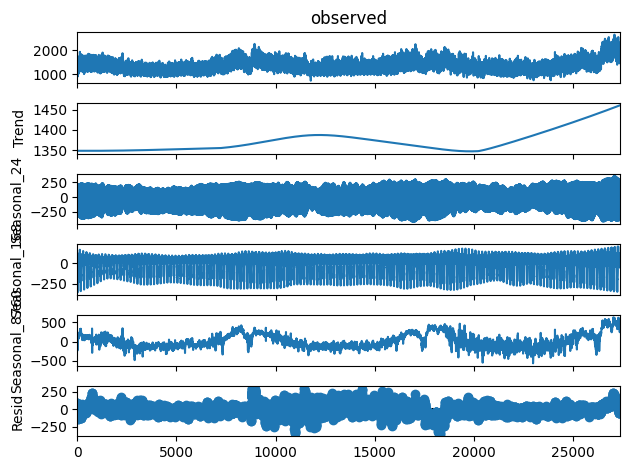

In [71]:
from statsmodels.tsa.seasonal import MSTL

mstl = MSTL(data['value'], periods=[24, 168, 8760])
result = mstl.fit()

result.plot()
plt.show()

<Axes: >

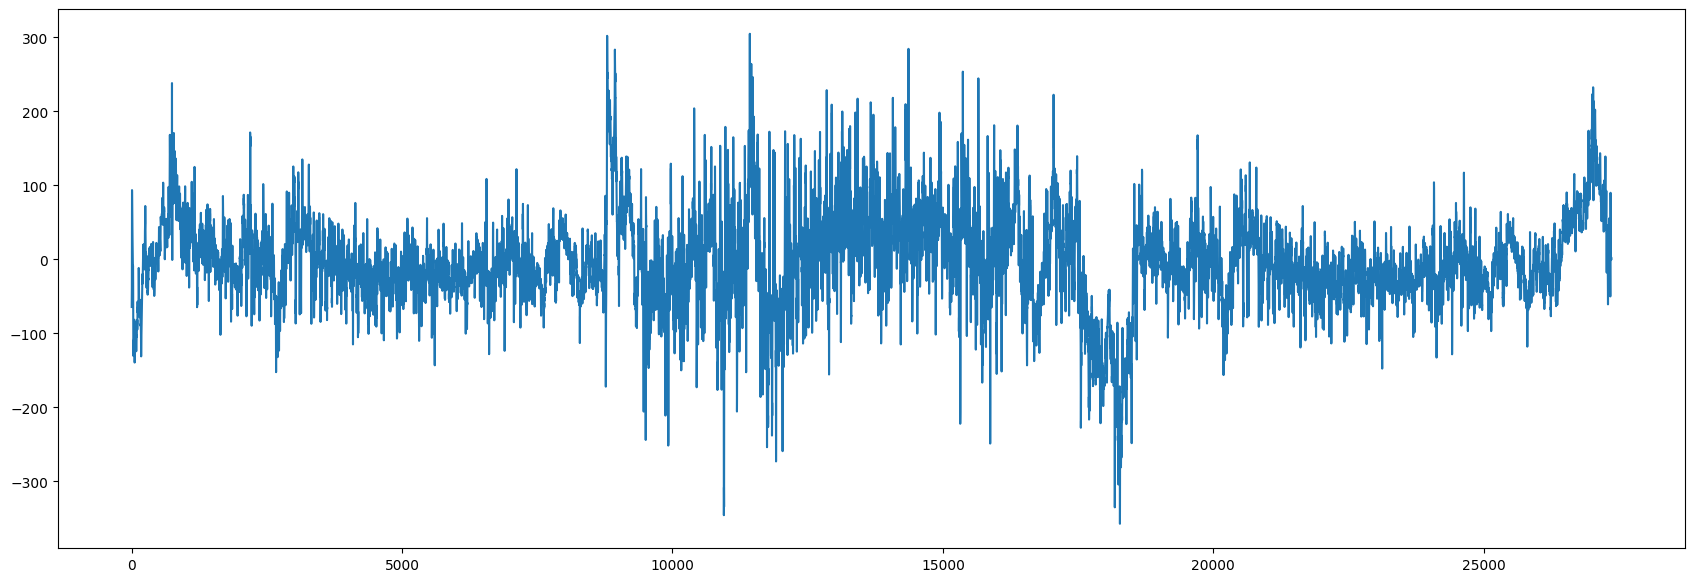

In [72]:
result.resid.plot(figsize=(21, 7))

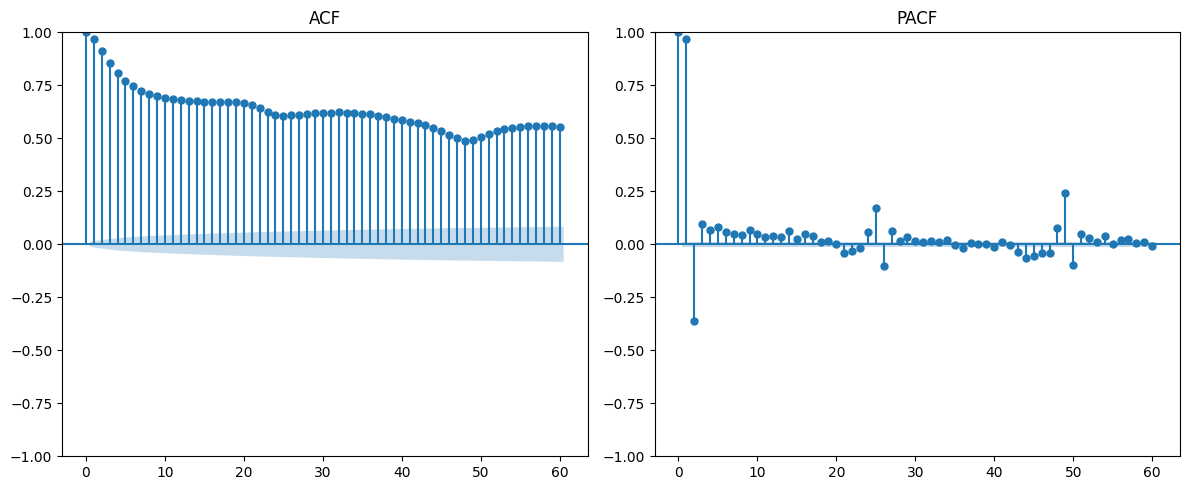

In [73]:
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

plot_acf(result.resid,
         lags=60,
         ax=axs[0])
axs[0].set_title("ACF")

plot_pacf(result.resid,
          lags=60,
          ax=axs[1])
axs[1].set_title('PACF')

plt.tight_layout()
plt.show()

In [74]:
print(acorr_ljungbox(result.resid, period=24)['lb_pvalue'].max())
print(acorr_ljungbox(result.resid, period=168)['lb_pvalue'].max())
print(acorr_ljungbox(result.resid, period=8760)['lb_pvalue'].max())

0.0
0.0
0.0


Even after decomposing the time series residuals still carry some information. The ACF function no longer shows clear daily seasonality. This might indicate that exogenous variables could play a role in predicting energy demand. 

In [75]:
from statsforecast import StatsForecast
from statsforecast.models import AutoARIMA

/home/user/Documents/repositories/power-forecast/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [76]:
data

,value,ltu,utc,date,day_of_week,month,year,temp
0,978.868,2023-01-01 02:00:00,2023-01-01 00:00:00,2023-01-01,6,1,2023,9.558685
1,947.675,2023-01-01 03:00:00,2023-01-01 01:00:00,2023-01-01,6,1,2023,9.558685
2,937.409,2023-01-01 04:00:00,2023-01-01 02:00:00,2023-01-01,6,1,2023,9.591937
3,933.605,2023-01-01 05:00:00,2023-01-01 03:00:00,2023-01-01,6,1,2023,9.468869
4,961.825,2023-01-01 06:00:00,2023-01-01 04:00:00,2023-01-01,6,1,2023,9.398759
...,...,...,...,...,...,...,...,...
27355,1847.633,2026-02-13 21:00:00,2026-02-13 19:00:00,2026-02-13,4,2,2026,-2.008733
27356,1741.394,2026-02-13 22:00:00,2026-02-13 20:00:00,2026-02-13,4,2,2026,-2.149886
27357,1643.696,2026-02-13 23:00:00,2026-02-13 21:00:00,2026-02-13,4,2,2026,-2.645182
27358,1574.306,2026-02-14 00:00:00,2026-02-13 22:00:00,2026-02-14,5,2,2026,-2.789725


In [77]:
data['unique_id'] = 'Lithuania'

sf = StatsForecast(
    models=[AutoARIMA(d=0,
                      D=0,
                      season_length=168,
                      approximation=True)],
    freq='h',
    n_jobs=-1
)

sf.fit(data[['unique_id', 'utc', 'value']], 
       id_col='unique_id', 
       time_col='utc', 
       target_col='value')

/home/user/Documents/repositories/power-forecast/.venv/lib/python3.12/site-packages/statsforecast/arima.py:486: UserWarning: possible convergence problem: minimize gave code 2]
  warnings.warn(
/home/user/Documents/repositories/power-forecast/.venv/lib/python3.12/site-packages/statsforecast/arima.py:486: UserWarning: possible convergence problem: minimize gave code 2]
  warnings.warn(
/home/user/Documents/repositories/power-forecast/.venv/lib/python3.12/site-packages/statsforecast/arima.py:486: UserWarning: possible convergence problem: minimize gave code 2]
  warnings.warn(
/home/user/Documents/repositories/power-forecast/.venv/lib/python3.12/site-packages/statsforecast/arima.py:486: UserWarning: possible convergence problem: minimize gave code 2]
  warnings.warn(
/home/user/Documents/repositories/power-forecast/.venv/lib/python3.12/site-packages/statsforecast/arima.py:486: UserWarning: possible convergence problem: minimize gave code 2]
  warnings.warn(
/home/user/Documents/repositor

StatsForecast(models=[AutoARIMA])

In [78]:
from statsforecast.arima import arima_string

arima_string(sf.fitted_[0,0].model_)

'ARIMA(3,0,1) with non-zero mean'

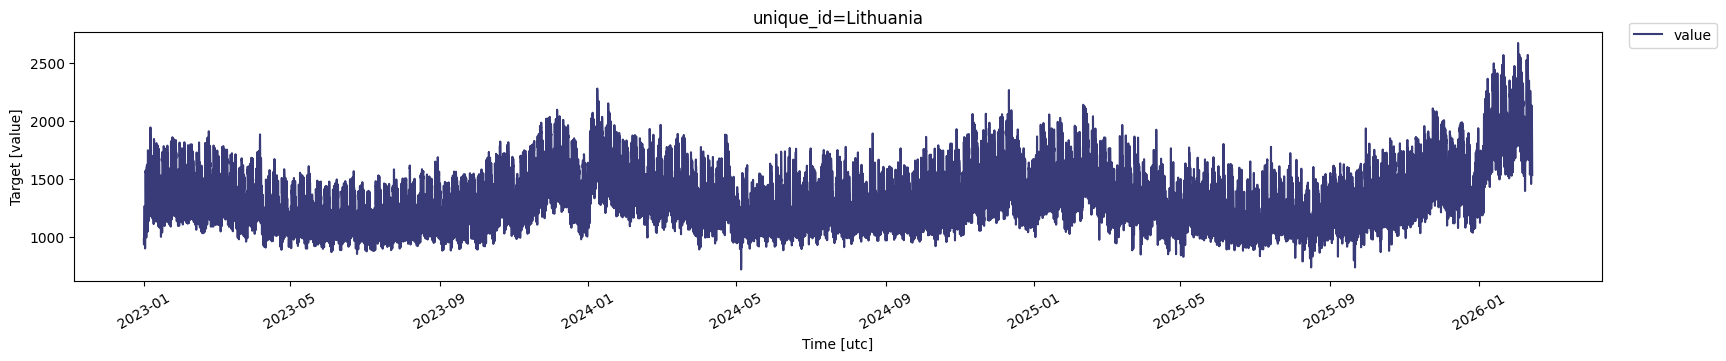

In [79]:
sf.plot(data[['unique_id', 'utc', 'value']], 
       id_col='unique_id', 
       time_col='utc', 
       target_col='value')

In [ ]:
from pmdarima import auto_arima

arima_model = auto_arima(y=data['value'],
                         X=data[['day_of_week', 'month', 'year', 'temp']],
                         d=0,
                         D=0,
                         trace=True,
                         m=24)

Performing stepwise search to minimize aic
 ARIMA(2,0,2)(1,0,1)[24] intercept   : AIC=inf, Time=187.68 sec
 ARIMA(0,0,0)(0,0,0)[24] intercept   : AIC=379264.015, Time=1.35 sec
 ARIMA(1,0,0)(1,0,0)[24] intercept   : AIC=inf, Time=127.16 sec
 ARIMA(0,0,1)(0,0,1)[24] intercept   : AIC=328684.988, Time=123.72 sec
 ARIMA(0,0,0)(0,0,0)[24]             : AIC=379262.019, Time=13.08 sec
 ARIMA(0,0,1)(0,0,0)[24] intercept   : AIC=345970.827, Time=14.36 sec
 ARIMA(0,0,1)(1,0,1)[24] intercept   : AIC=309674.392, Time=160.70 sec
 ARIMA(0,0,1)(1,0,0)[24] intercept   : AIC=312388.406, Time=149.70 sec
 ARIMA(0,0,1)(2,0,1)[24] intercept   : AIC=inf, Time=554.55 sec
 ARIMA(0,0,1)(1,0,2)[24] intercept   : AIC=inf, Time=566.06 sec


In [ ]:
arima_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                27361
Model:               SARIMAX(4, 0, 1)   Log Likelihood             -144378.060
Date:                Tue, 17 Feb 2026   AIC                         288776.120
Time:                        23:06:44   BIC                         288858.289
Sample:                             0   HQIC                        288802.601
                              - 27361                                         
Covariance Type:                  opg                                         
===============================================================================
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
intercept       0.8754     19.292      0.045      0.964     -36.935      38.686
day_of_week    -1.1422      0.743     -1.537      0.124      -2.599       0.314
month          -7.5350      1.442     -5.225      0.000     -10.362      -4.708
year            0.0693     14.380      0.005      0.996     -28.114      28.253
ar.L1           2.7748      0.005    525.107      0.000       2.764       2.785
ar.L2          -2.7858      0.013   -217.006      0.000      -2.811      -2.761
ar.L3           1.1369      0.013     88.381      0.000       1.112       1.162
ar.L4          -0.1265      0.005    -24.888      0.000      -0.136      -0.117
ma.L1          -0.9668      0.003   -317.062      0.000      -0.973      -0.961
sigma2       2249.9781     12.880    174.692      0.000    2224.734    2275.222
===================================================================================
Ljung-Box (L1) (Q):                   0.06   Jarque-Bera (JB):             29541.92
Prob(Q):                              0.81   Prob(JB):                         0.00
Heteroskedasticity (H):               1.33   Skew:                             0.59
Prob(H) (two-sided):                  0.00   Kurtosis:                         7.95
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

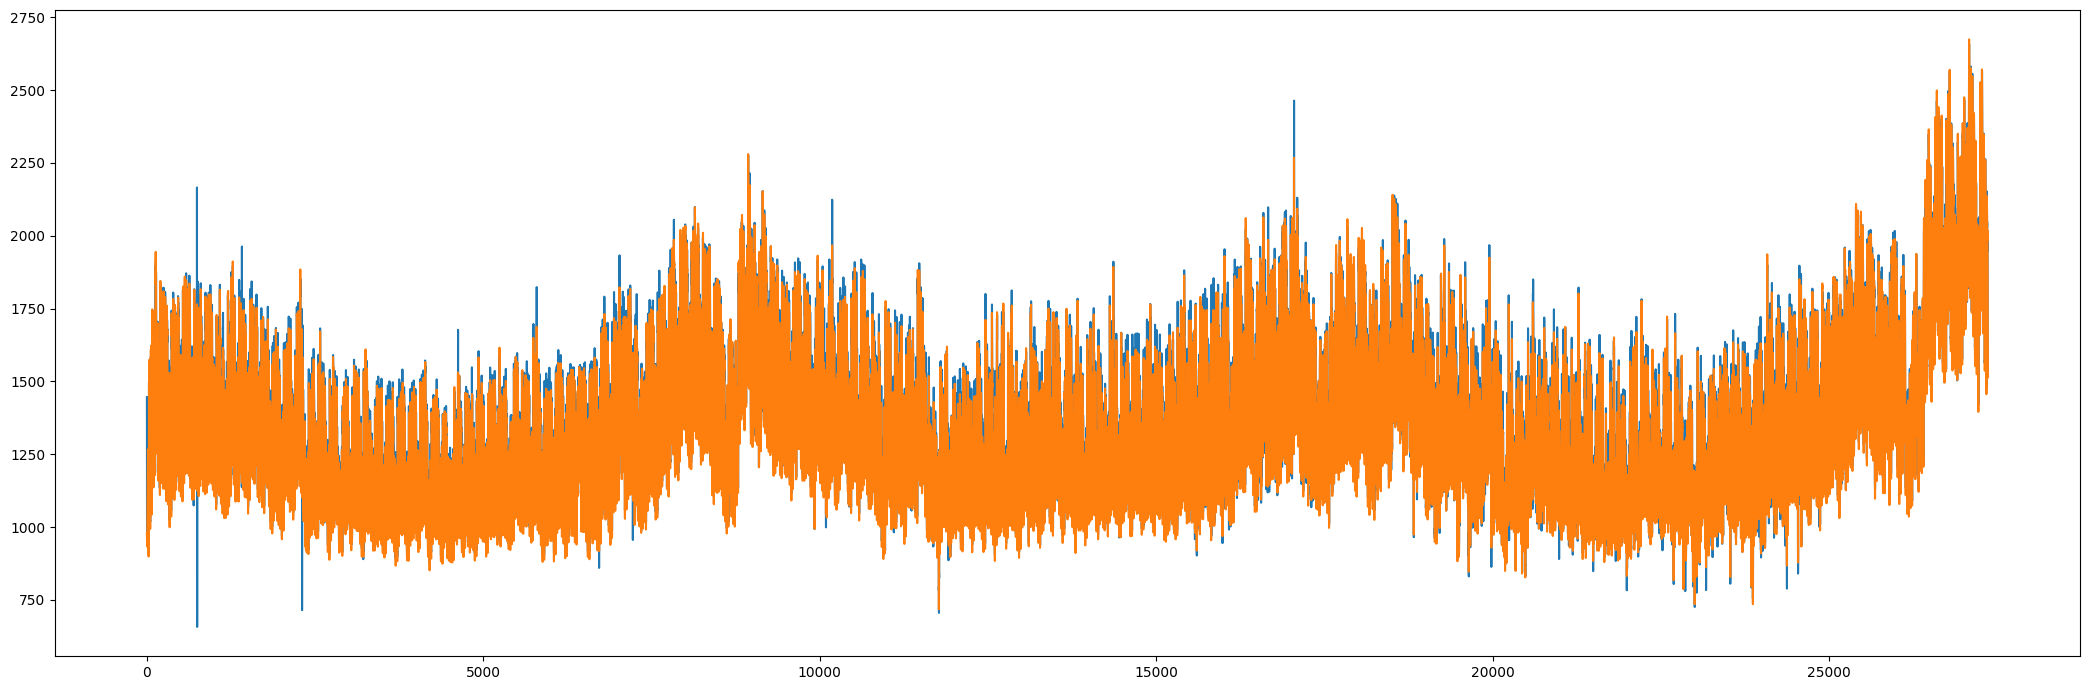

In [ ]:
arima_model.fittedvalues().plot(figsize=(21, 7))
data['value'].plot()

plt.tight_layout()
plt.show()

<Axes: >

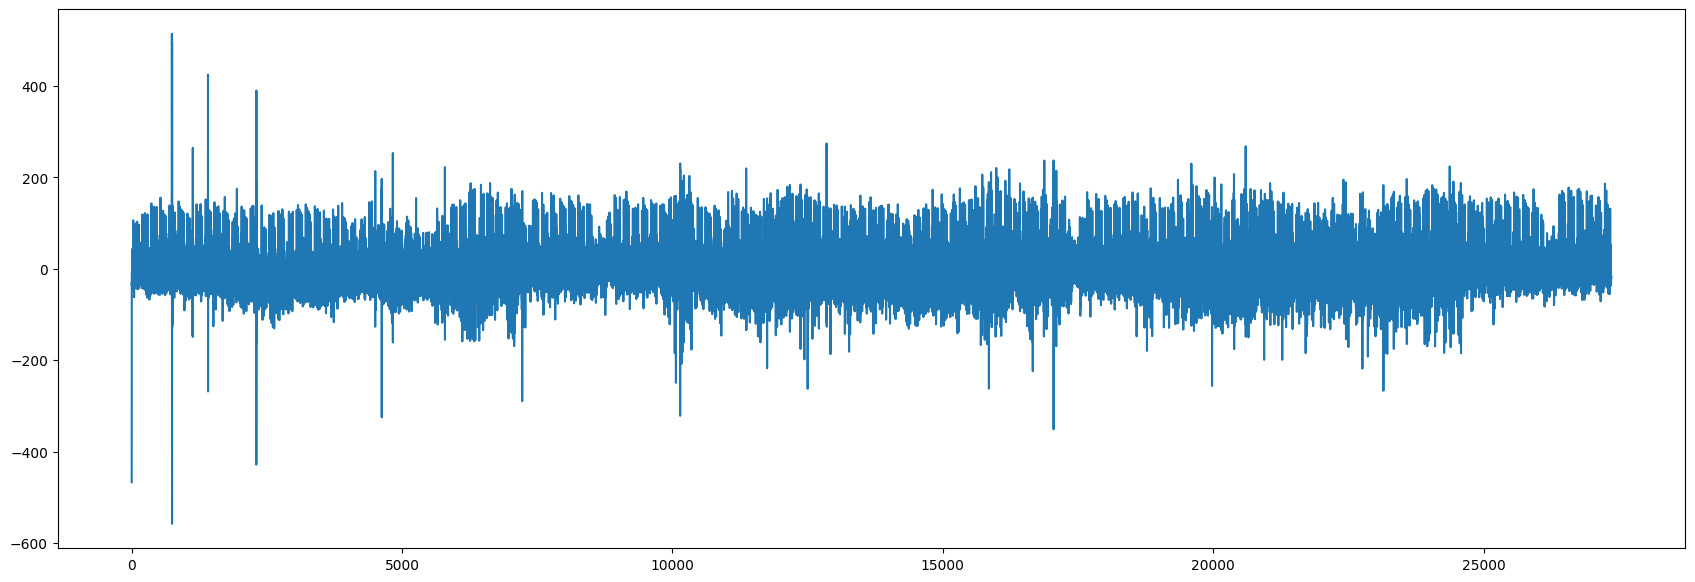

In [ ]:
arima_model.resid().plot(figsize=(21, 7))